<a href="https://colab.research.google.com/github/dneguja/neguja.cse-davprojects/blob/main/statistical_data_descriptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXAMPLE 1: SINGLE VARIABLE DATA
----------------------------------------
COMPLETE STATISTICAL DATA DESCRIPTION

1. BASIC INFORMATION:
Dataset shape: (210,)
Number of observations: 210

2. MEASURES OF CENTRAL TENDENCY:
{'mean': np.float64(103.48196524312333), 'median': 101.02068384620463, 'mode': np.float64(60.703823438653835)}

3. MEASURES OF DISPERSION:
{'range': 134.95820418916972, 'variance': 527.3538324302659, 'std_dev': 22.964185864738727, 'iqr': np.float64(19.849631698219426)}

4. MEASURES OF SHAPE:
{'skewness': np.float64(2.1180559844223117), 'kurtosis': np.float64(6.030498554555983)}

5. FIVE NUMBER SUMMARY:
{'minimum': 60.703823438653835, 'Q1': np.float64(89.96542841678875), 'median': 101.02068384620463, 'Q3': np.float64(109.81506011500818), 'maximum': 195.66202762782356}

6. QUANTILES:
1.0%: 70.66
5.0%: 77.92
10.0%: 81.67
25.0%: 89.97
50.0%: 101.02
75.0%: 109.82
90.0%: 122.87
95.0%: 139.07
99.0%: 193.10

7. OUTLIER DETECTION (IQR method):
11 outliers detected
Values: [140.802

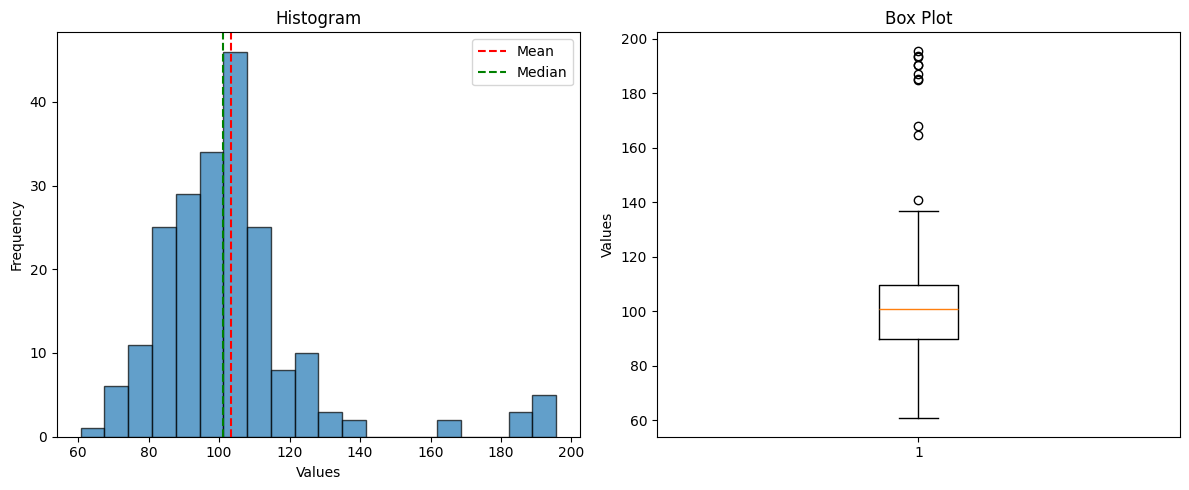


EXAMPLE 2: MULTIPLE VARIABLES (DATAFRAME)
COMPLETE STATISTICAL DATA DESCRIPTION

1. BASIC INFORMATION:
Dataset shape: (500, 4)
Number of observations: 500

2. MEASURES OF CENTRAL TENDENCY:
                          mean        median         mode
Age                  34.972410     34.812353     2.587327
Income            52762.270362  52227.615859  6556.169327
Years_Experience      7.888000      8.000000     7.000000
Score                79.779011     79.790911    60.156735

3. MEASURES OF DISPERSION:
                          range      variance       std_dev           iqr
Age                   70.939988  1.025212e+02     10.125275     13.648962
Income            219784.367246  3.512183e+08  18740.818688  19454.679404
Years_Experience      15.000000  7.390236e+00      2.718499      4.000000
Score                 39.821692  1.321573e+02     11.495968     19.822155

4. MEASURES OF SHAPE:
                  skewness   kurtosis
Age               0.136008   0.197091
Income            2.672

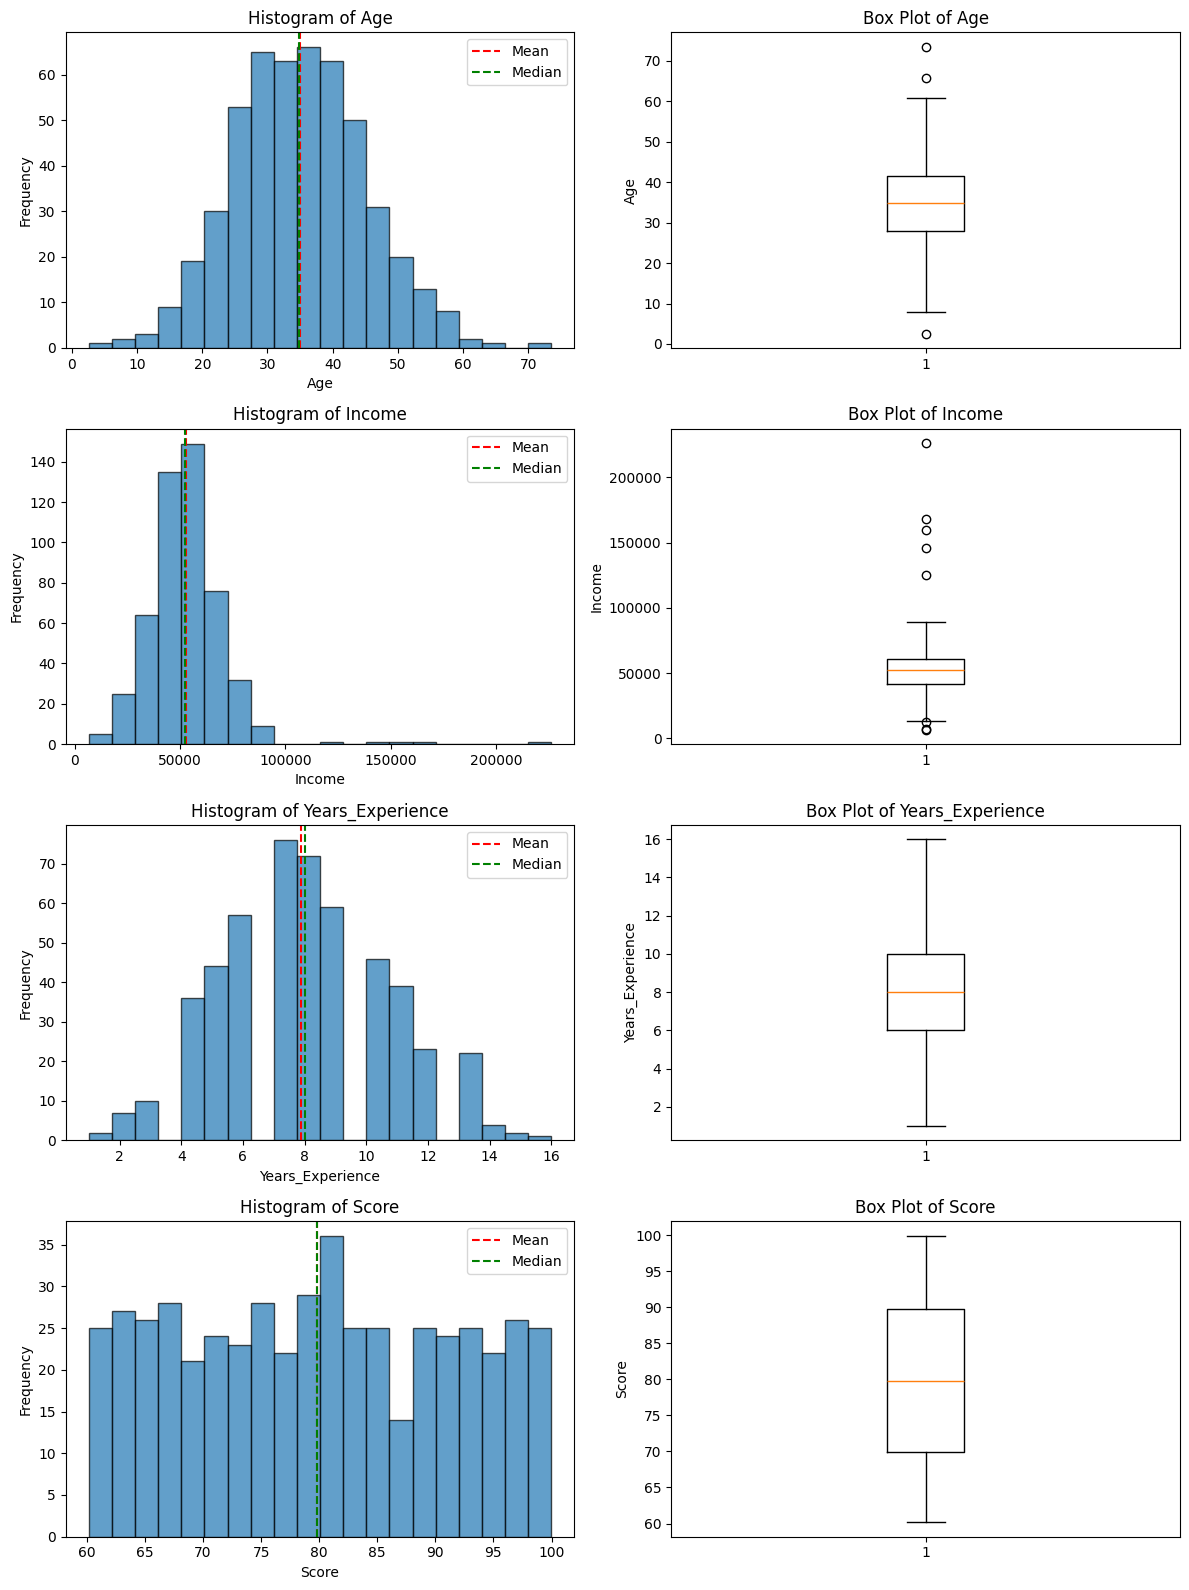


PANDAS BUILT-IN DESCRIBE METHOD
              Age         Income  Years_Experience       Score
count  500.000000     500.000000        500.000000  500.000000
mean    34.972410   52762.270362          7.888000   79.779011
std     10.125275   18740.818688          2.718499   11.495968
min      2.587327    6556.169327          1.000000   60.156735
25%     27.991199   41705.492527          6.000000   69.890454
50%     34.812353   52227.615859          8.000000   79.790911
75%     41.640161   61160.171930         10.000000   89.712609
max     73.527315  226340.536573         16.000000   99.978427

CORRELATION MATRIX
                       Age    Income  Years_Experience     Score
Age               1.000000  0.085073         -0.010610 -0.016993
Income            0.085073  1.000000          0.040692 -0.024511
Years_Experience -0.010610  0.040692          1.000000 -0.016939
Score            -0.016993 -0.024511         -0.016939  1.000000


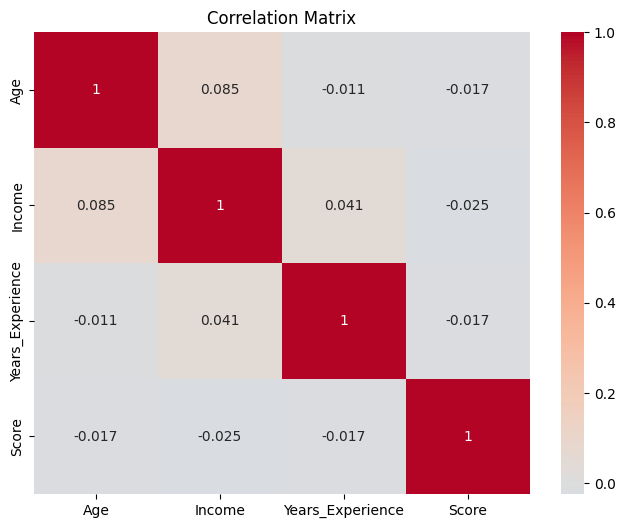

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

class StatisticalDataDescription:
    """A comprehensive class for statistical data description"""

    def __init__(self, data):
        """
        Initialize with data

        Parameters:
        data: list, numpy array, or pandas Series/DataFrame
        """
        if isinstance(data, pd.DataFrame):
            self.data = data
            self.is_dataframe = True
        else:
            self.data = pd.Series(data)
            self.is_dataframe = False

    def measures_of_central_tendency(self):
        """Calculate measures of central tendency"""
        if self.is_dataframe:
            result = {}
            for col in self.data.columns:
                if self.data[col].dtype in ['int64', 'float64']:
                    result[col] = {
                        'mean': self.data[col].mean(),
                        'median': self.data[col].median(),
                        'mode': self.data[col].mode().values[0] if len(self.data[col].mode()) > 0 else None
                    }
            return pd.DataFrame(result).T
        else:
            return {
                'mean': self.data.mean(),
                'median': self.data.median(),
                'mode': self.data.mode().values[0] if len(self.data.mode()) > 0 else None
            }

    def measures_of_dispersion(self):
        """Calculate measures of dispersion/spread"""
        if self.is_dataframe:
            result = {}
            for col in self.data.columns:
                if self.data[col].dtype in ['int64', 'float64']:
                    result[col] = {
                        'range': self.data[col].max() - self.data[col].min(),
                        'variance': self.data[col].var(),
                        'std_dev': self.data[col].std(),
                        'iqr': self.data[col].quantile(0.75) - self.data[col].quantile(0.25)
                    }
            return pd.DataFrame(result).T
        else:
            return {
                'range': self.data.max() - self.data.min(),
                'variance': self.data.var(),
                'std_dev': self.data.std(),
                'iqr': self.data.quantile(0.75) - self.data.quantile(0.25)
            }

    def measures_of_shape(self):
        """Calculate measures of distribution shape"""
        if self.is_dataframe:
            result = {}
            for col in self.data.columns:
                if self.data[col].dtype in ['int64', 'float64']:
                    result[col] = {
                        'skewness': self.data[col].skew(),
                        'kurtosis': self.data[col].kurtosis()
                    }
            return pd.DataFrame(result).T
        else:
            return {
                'skewness': self.data.skew(),
                'kurtosis': self.data.kurtosis()
            }

    def quantiles(self):
        """Calculate various quantiles"""
        quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

        if self.is_dataframe:
            result = {}
            for col in self.data.columns:
                if self.data[col].dtype in ['int64', 'float64']:
                    result[col] = {f'{q*100}%': self.data[col].quantile(q) for q in quantiles}
            return pd.DataFrame(result).T
        else:
            return {f'{q*100}%': self.data.quantile(q) for q in quantiles}

    def frequency_distribution(self, bins=10):
        """Create frequency distribution"""
        if self.is_dataframe:
            result = {}
            for col in self.data.columns:
                if self.data[col].dtype in ['int64', 'float64']:
                    freq_dist = pd.cut(self.data[col], bins=bins)
                    result[col] = freq_dist.value_counts().sort_index()
            return result
        else:
            freq_dist = pd.cut(self.data, bins=bins)
            return freq_dist.value_counts().sort_index()

    def five_number_summary(self):
        """Calculate five number summary"""
        if self.is_dataframe:
            result = {}
            for col in self.data.columns:
                if self.data[col].dtype in ['int64', 'float64']:
                    result[col] = {
                        'minimum': self.data[col].min(),
                        'Q1': self.data[col].quantile(0.25),
                        'median': self.data[col].median(),
                        'Q3': self.data[col].quantile(0.75),
                        'maximum': self.data[col].max()
                    }
            return pd.DataFrame(result).T
        else:
            return {
                'minimum': self.data.min(),
                'Q1': self.data.quantile(0.25),
                'median': self.data.median(),
                'Q3': self.data.quantile(0.75),
                'maximum': self.data.max()
            }

    def detect_outliers(self, method='iqr'):
        """Detect outliers using IQR or Z-score method"""
        outliers = {}

        if method == 'iqr':
            if self.is_dataframe:
                for col in self.data.columns:
                    if self.data[col].dtype in ['int64', 'float64']:
                        Q1 = self.data[col].quantile(0.25)
                        Q3 = self.data[col].quantile(0.75)
                        IQR = Q3 - Q1
                        lower_bound = Q1 - 1.5 * IQR
                        upper_bound = Q3 + 1.5 * IQR
                        outliers[col] = self.data[col][(self.data[col] < lower_bound) |
                                                      (self.data[col] > upper_bound)]
            else:
                Q1 = self.data.quantile(0.25)
                Q3 = self.data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = self.data[(self.data < lower_bound) | (self.data > upper_bound)]

        elif method == 'zscore':
            if self.is_dataframe:
                for col in self.data.columns:
                    if self.data[col].dtype in ['int64', 'float64']:
                        z_scores = np.abs(stats.zscore(self.data[col].dropna()))
                        outliers[col] = self.data[col][z_scores > 3]
            else:
                z_scores = np.abs(stats.zscore(self.data.dropna()))
                outliers = self.data[z_scores > 3]

        return outliers

    def complete_description(self):
        """Generate complete statistical description"""
        print("=" * 80)
        print("COMPLETE STATISTICAL DATA DESCRIPTION")
        print("=" * 80)

        # Basic info
        print("\n1. BASIC INFORMATION:")
        print(f"Dataset shape: {self.data.shape}")
        print(f"Number of observations: {len(self.data)}")

        # Central tendency
        print("\n2. MEASURES OF CENTRAL TENDENCY:")
        print(self.measures_of_central_tendency())

        # Dispersion
        print("\n3. MEASURES OF DISPERSION:")
        print(self.measures_of_dispersion())

        # Shape
        print("\n4. MEASURES OF SHAPE:")
        print(self.measures_of_shape())

        # Five number summary
        print("\n5. FIVE NUMBER SUMMARY:")
        print(self.five_number_summary())

        # Quantiles
        print("\n6. QUANTILES:")
        quantiles_result = self.quantiles()
        if isinstance(quantiles_result, pd.DataFrame):
            print(quantiles_result)
        else:
            for q, val in quantiles_result.items():
                print(f"{q}: {val:.2f}")

        # Outliers
        print("\n7. OUTLIER DETECTION (IQR method):")
        outliers = self.detect_outliers('iqr')
        if isinstance(outliers, dict):
            for col, out in outliers.items():
                print(f"{col}: {len(out)} outliers detected")
                if len(out) > 0:
                    print(f"  Values: {out.values[:5] if len(out) > 5 else out.values}")
        else:
            print(f"{len(outliers)} outliers detected")
            if len(outliers) > 0:
                print(f"Values: {outliers.values[:5] if len(outliers) > 5 else outliers.values}")

    def visualize(self):
        """Create visualization plots"""
        if self.is_dataframe:
            numeric_cols = self.data.select_dtypes(include=[np.number]).columns
            n_cols = len(numeric_cols)

            if n_cols == 0:
                print("No numeric columns to visualize")
                return

            fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4*n_cols))
            if n_cols == 1:
                axes = axes.reshape(1, -1)

            for idx, col in enumerate(numeric_cols):
                # Histogram
                axes[idx, 0].hist(self.data[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
                axes[idx, 0].set_title(f'Histogram of {col}')
                axes[idx, 0].set_xlabel(col)
                axes[idx, 0].set_ylabel('Frequency')
                axes[idx, 0].axvline(self.data[col].mean(), color='red', linestyle='--', label='Mean')
                axes[idx, 0].axvline(self.data[col].median(), color='green', linestyle='--', label='Median')
                axes[idx, 0].legend()

                # Box plot
                axes[idx, 1].boxplot(self.data[col].dropna())
                axes[idx, 1].set_title(f'Box Plot of {col}')
                axes[idx, 1].set_ylabel(col)

            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            # Histogram
            axes[0].hist(self.data.dropna(), bins=20, edgecolor='black', alpha=0.7)
            axes[0].set_title('Histogram')
            axes[0].set_xlabel('Values')
            axes[0].set_ylabel('Frequency')
            axes[0].axvline(self.data.mean(), color='red', linestyle='--', label='Mean')
            axes[0].axvline(self.data.median(), color='green', linestyle='--', label='Median')
            axes[0].legend()

            # Box plot
            axes[1].boxplot(self.data.dropna())
            axes[1].set_title('Box Plot')
            axes[1].set_ylabel('Values')

            plt.tight_layout()
            plt.show()


# Example usage and demonstration
def main():
    # Generate sample data
    np.random.seed(42)

    # Example 1: Single variable data
    print("EXAMPLE 1: SINGLE VARIABLE DATA")
    print("-" * 40)

    # Generate normal distribution with some outliers
    normal_data = np.random.normal(100, 15, 200)
    outliers_data = np.random.uniform(150, 200, 10)
    single_data = np.concatenate([normal_data, outliers_data])

    # Create statistical description object
    stat_single = StatisticalDataDescription(single_data)

    # Get complete description
    stat_single.complete_description()

    # Visualize
    print("\n8. VISUALIZATION:")
    stat_single.visualize()

    # Example 2: Multiple variables (DataFrame)
    print("\n" + "="*80)
    print("EXAMPLE 2: MULTIPLE VARIABLES (DATAFRAME)")
    print("="*80)

    # Create sample DataFrame
    df = pd.DataFrame({
        'Age': np.random.normal(35, 10, 500),
        'Income': np.random.normal(50000, 15000, 500),
        'Years_Experience': np.random.poisson(8, 500),
        'Score': np.random.uniform(60, 100, 500)
    })

    # Add some outliers
    df.loc[0:5, 'Income'] = df.loc[0:5, 'Income'] * 3

    # Create statistical description object for DataFrame
    stat_df = StatisticalDataDescription(df)

    # Get complete description
    stat_df.complete_description()

    # Visualize
    print("\n8. VISUALIZATION:")
    stat_df.visualize()

    # Example 3: Using pandas built-in describe
    print("\n" + "="*80)
    print("PANDAS BUILT-IN DESCRIBE METHOD")
    print("="*80)
    print(df.describe())

    # Additional correlation analysis for DataFrame
    if stat_df.is_dataframe:
        print("\n" + "="*80)
        print("CORRELATION MATRIX")
        print("="*80)
        correlation_matrix = df.corr()
        print(correlation_matrix)

        # Visualize correlation matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix')
        plt.show()


if __name__ == "__main__":
    main()